# Lasso Regression / L1 Regularization

- In Lasso regression, we add a penalty term to the cost function which is the absolute value of the coefficients multiplied by a regularization parameter $\lambda$.

- The cost function for Lasso regression is given by:


$$ L(W) = MSE + \lambda ||W||_1$$

$$ L(W) = MSE + \lambda \sum_{j=1}^{n} |W_j| $$

where j : is the number of features, $W_j$ is the coefficient for the j-th feature, and $\lambda$ is the regularization parameter.


- Let's see the code implementation:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

[27.19650966]
-1.4577015935238522


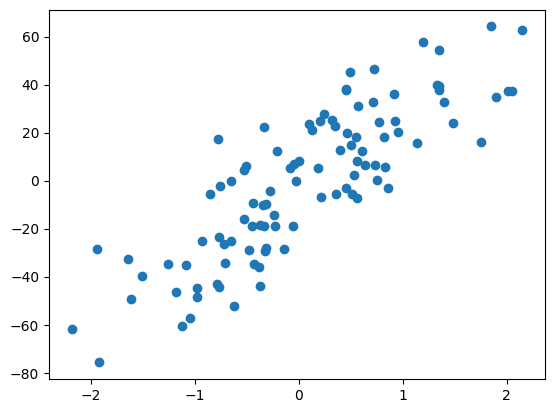

In [2]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train,y_train)
print(reg.coef_)
print(reg.intercept_)

- Plotting the regression line for different values of alpha (lambda) for 1-dimensional data:

c:\Users\Kaushik Mandal\.virtualenvs\ClassicalML-_wR1sNSC\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\Kaushik Mandal\.virtualenvs\ClassicalML-_wR1sNSC\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\Kaushik Mandal\.virtualenvs\ClassicalML-_wR1sNSC\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.195e+04, tolerance: 7.629e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers imp

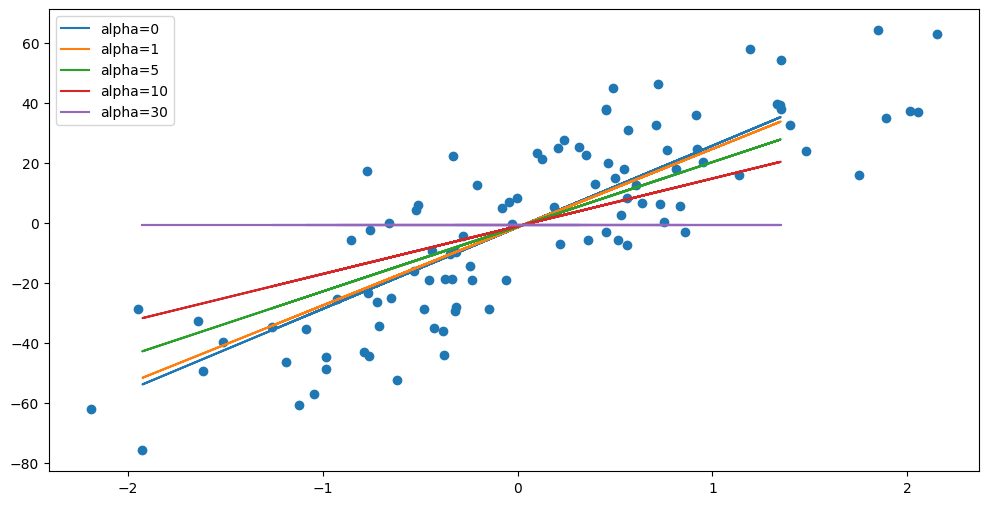

In [4]:
alphas = [0,1,5,10,30] # plotting the regression line for different values of alpha (lambda)
plt.figure(figsize=(12,6))
plt.scatter(X,y)

coefficients = np.array([])
for i in alphas:
    L = Lasso(alpha=i)
    L.fit(X_train,y_train)
    plt.plot(X_test,L.predict(X_test),label='alpha={}'.format(i))
    coefficients = np.append(coefficients,L.coef_)
plt.legend()
plt.show()
    

In [10]:
lasso_coefficients = pd.DataFrame({'alpha':alphas,'coefficients':coefficients})
lasso_coefficients

,alpha,coefficients
0,0,27.196510
1,1,26.067245
2,5,21.550187
3,10,15.903864
4,30,0.000000


- You can see as we increase the value of $\lambda$ , the coefficients (here only $m$) of the features are getting smaller and smaller (here the slope is decreasing) and at $\lambda = 30$, $m$ become zero. (which is a clear case of underfitting)

- Where as in ridge regression, the coefficients were getting smaller but never become zero.

### Lasso Regression Implementation in non-linear data

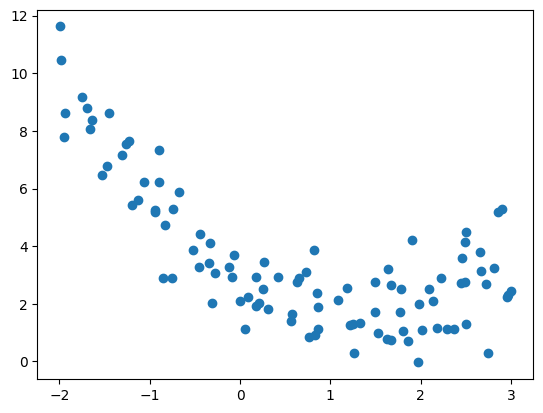

In [11]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

c:\Users\Kaushik Mandal\.virtualenvs\ClassicalML-_wR1sNSC\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\Kaushik Mandal\.virtualenvs\ClassicalML-_wR1sNSC\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\Kaushik Mandal\.virtualenvs\ClassicalML-_wR1sNSC\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.220e+01, tolerance: 6.064e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers imp

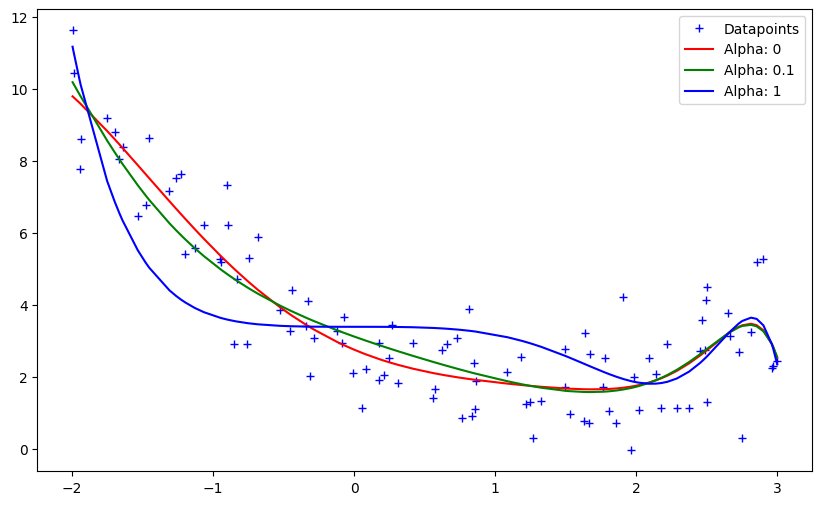

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

def get_preds_lasso(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('lasso', Lasso(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 0.1, 1]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_lasso(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

- The green line (alpha=0.1) is the best fit for the data, the red line (alpha=0) is overfitting the data and the blue line (alpha=1) is underfitting the data.

- Till now the only big difference we have seen between ridge and lasso regression is that in ridge regression, the coefficients of the features are getting smaller but never become zero, whereas in lasso regression, the coefficients of the features are getting smaller and smaller and at some point they become zero.

# The benefit of the coefficients becoming zero in lasso regression:

- When we work with high dimensional data (data with a large number of features), if we try to fit a polynomial regression model to the data, we can very easily end up with a very complex model which will overfit the data.

- If we implement **ridge regression**, we can reduce the complexity of the model by reducing the coefficients of the features but they will never become zero, so we will have to keep all the features in the model. {Usko pata toh chal jata hai ki kaunse features important nahi hai, but it can't remove those features from the model}

- <span style="color:orange">If we implement **lasso regression**, and hum thoda vhi value increase krte hai $\lambda$ ka , then jo features kam important hai, unke coefficients zero ho jayenge</span>

### So we are inherently performing feature selection in lasso regression, which is a very good thing when we are working with high dimensional data as the dimensionality of the data is reduced 


- So in general we prefer to use lasso regression when we are working with high dimensional data and some of the features are not important, as lasso regression will automatically perform feature selection for us and remove the unimportant features from the model.